# The mathematics behind the car price notebooks

This is the third notebook in the project. The first two build the same car price model twice:

- [`car-price-prediction.ipynb`](car-price-prediction.ipynb), from scratch with NumPy, and
- [`car-price-prediction-scikit-learn.ipynb`](car-price-prediction-scikit-learn.ipynb), with scikit-learn.

Along the way, several things happened that deserve a proper explanation. The NumPy model broke three times, always for the same reason. scikit-learn trained through the same three cases without complaint. Ridge regression fixed everything by adding a small number to a diagonal. And one scikit-learn solver gave up half-way until the columns were rescaled.

This notebook explains why, twice:

- **Part I** uses plain language and tiny examples built from four real cars in the dataset. It needs nothing beyond arithmetic.
- **Part II** says the same things in the language of linear algebra: column spaces, rank, null spaces, singular values. Each of its sections points back to the Part I section it makes precise. It assumes you know what vectors, matrices, matrix multiplication, the transpose and the inverse are.

**Contents**

*Part I: the ideas in plain language*

1. A model is a recipe for a price
2. The best weights leave no pattern in the errors
3. Why we predict the log of the price
4. Categories become 0/1 columns
5. The slide: when the best weights are not unique
6. Three disguises of the same problem
7. Why the computer didn't complain
8. Three ways out
9. Why step-by-step solvers need rescaled columns

*Part II: the same ideas in linear algebra*

10. Notation, and the real data
11. Least squares is a projection
12. Uniqueness: rank and null space
13. Why `inv` fails: singular values and the condition number
14. What `lstsq` returns: the pseudoinverse
15. Dropping a column keeps the column space
16. Ridge regression, formally
17. Conditioning and gradient descent
18. Summary: one table, two languages

## Setup

The same environment as the other two notebooks. scikit-learn is used only once, in section 14, to confirm a result.

```bash
python -m venv .venv
.venv\Scripts\activate          # Windows
source .venv/bin/activate       # macOS / Linux
pip install numpy pandas scikit-learn matplotlib ipykernel
```

In [1]:
import numpy as np
import pandas as pd

# Print small numbers as plain decimals instead of scientific notation.
np.set_printoptions(suppress=True, linewidth=120)

In [2]:
# Every chart in this notebook shares one look: a light background, thin grey gridlines, and a fixed order
# of colors (blue, then orange, then green), so that a color keeps its meaning within a chart.
import matplotlib.pyplot as plt

BLUE, ORANGE, GREEN, GREY = '#2a78d6', '#eb6834', '#1baf7a', '#898781'
BACKGROUND, INK = '#fcfcfb', '#0b0b0b'

plt.rcParams.update({
    'figure.figsize': (8, 4.5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.titlelocation': 'left',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.color': '#e1e0d9',
    'grid.linewidth': 0.8,
    'xtick.color': '#52514e',
    'ytick.color': '#52514e',
    'text.color': INK,
    'legend.frameon': False,
    'lines.linewidth': 2,
    'axes.prop_cycle': plt.cycler(color=[BLUE, ORANGE, GREEN]),
})

## Part I: The ideas in plain language

Throughout Part I we use four real 2017 cars from `data.csv`, with their prices in dollars. (The real notebooks predict the log of the price, and section 3 explains why; for building intuition, dollars are easier to read.)

### 1. A model is a recipe for a price

A linear regression model predicts a price with a fixed recipe: start from a base amount, then add a fixed amount for every unit of every feature. With one feature:

```
predicted price = bias + weight × engine_hp
```

The **bias** is the starting amount, and a **weight** is simply a number that the model multiplies a feature by. Choosing a model means choosing these numbers. Here are our four cars and one guess.

In [3]:
cars = pd.DataFrame({
    'car': ['Ford Mustang', 'Ford Transit Wagon', 'Honda Civic', 'Toyota Camry'],
    'engine_hp': [310, 275, 174, 178],
    'doors': [2, 3, 4, 4],
    'price': [25645, 34515, 19700, 23070],
})

# A guess: start at $10,000 and add $50 per horsepower.
bias, weight = 10000, 50
cars['guess'] = bias + weight * cars.engine_hp
cars['error'] = cars.guess - cars.price     # positive: the guess is too high
cars

,car,engine_hp,doors,price,guess,error
0,Ford Mustang,310,2,25645,25500,-145
1,Ford Transit Wagon,275,3,34515,23750,-10765
2,Honda Civic,174,4,19700,18700,-1000
3,Toyota Camry,178,4,23070,18900,-4170


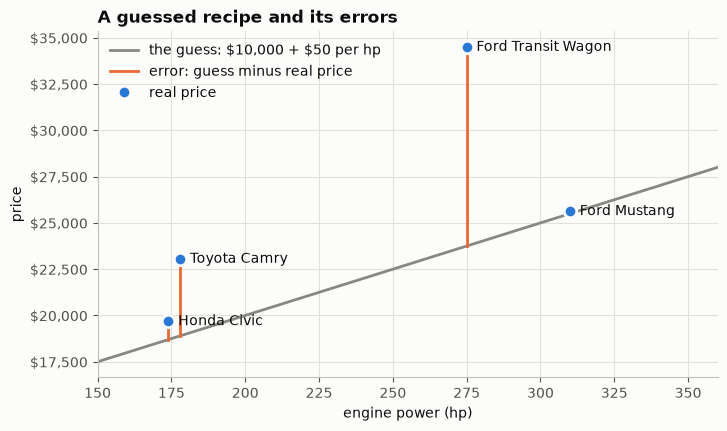

In [4]:
def draw_cars(ax):
    # The four cars as dots, each with its name.
    ax.plot(cars.engine_hp, cars.price, 'o', color=BLUE, markersize=9, markeredgecolor=BACKGROUND,
            markeredgewidth=2, label='real price', zorder=3)
    for _, car in cars.iterrows():
        ax.annotate(car.car, (car.engine_hp, car.price), xytext=(7, -3), textcoords='offset points')
    ax.set_xlabel('engine power (hp)')
    ax.set_ylabel('price')
    ax.yaxis.set_major_formatter(lambda value, _: f'${value:,.0f}')
    ax.set_xlim(150, 360)


hp_range = np.array([150, 360])
fig, ax = plt.subplots()
ax.plot(hp_range, bias + weight * hp_range, color=GREY, label=r'the guess: \$10,000 + \$50 per hp')
for _, car in cars.iterrows():
    ax.plot([car.engine_hp] * 2, [car.price, car.guess], color=ORANGE, linewidth=2)
ax.plot([], [], color=ORANGE, label='error: guess minus real price')
draw_cars(ax)
ax.set_title('A guessed recipe and its errors')
ax.legend(loc='upper left')
plt.show()

**Reading the chart.** Engine power is on the horizontal axis and price on the vertical axis, and each blue dot is one of the four cars. The grey line is the guessed recipe: for any horsepower, it gives the predicted price. The orange segments are the errors, the vertical distance from each car to the line. The Transit's is by far the longest: \$10,765.

The guess is close for the Mustang and \$10,765 too low for the Transit. Can we choose better numbers? First we need a way to score a guess.

### 2. The best weights leave no pattern in the errors

The usual score is the **sum of squared errors**: square each car's error, then add them up. Squaring makes every error count as positive, and it makes big errors count much more than small ones. It has a practical advantage too: the best weights can then be computed exactly, with one formula, instead of being searched for. Section 11 derives that formula; here we just use it.

In the code, `X` is the table of inputs, one row per car: a column of 1's (for the bias) and the horsepower. `X @ w` computes bias × 1 + weight × horsepower for every car at once.

In [5]:
X = np.column_stack([np.ones(4), cars.engine_hp])
y = cars.price.to_numpy(dtype=float)

def sum_of_squared_errors(w):
    errors = X @ w - y
    return (errors ** 2).sum()

# The formula of section 11 gives the best bias and weight:
w_best = np.linalg.solve(X.T @ X, X.T @ y)
print('best bias and weight:', w_best)
print(f'sum of squared errors: {sum_of_squared_errors(w_best):,.0f}')

# Nudging the best weights in any direction makes the score worse:
for nudge in [(0, 5), (1000, 0), (-1000, 5)]:
    print(f'  nudged by {nudge}: {sum_of_squared_errors(w_best + np.array(nudge)):,.0f}')

best bias and weight: [11464.29788096    60.91014779]
sum of squared errors: 67,964,168
  nudged by (0, 5): 73,806,293
  nudged by (1000, 0): 71,964,168
  nudged by (-1000, 5): 68,436,293


The best recipe is about \$11,464 plus \$60.91 per horsepower. What makes it the best? Look at its errors.

In [6]:
errors = X @ w_best - y
print('errors:', errors.round(2))
print(f'sum of the errors:          {errors.sum():.1e}')
print(f'sum of error × engine_hp:   {(errors * cars.engine_hp).sum():.1e}')

errors: [ 4701.44 -6300.41  2362.66  -763.7 ]
sum of the errors:          -7.3e-12
sum of error × engine_hp:   2.0e-10


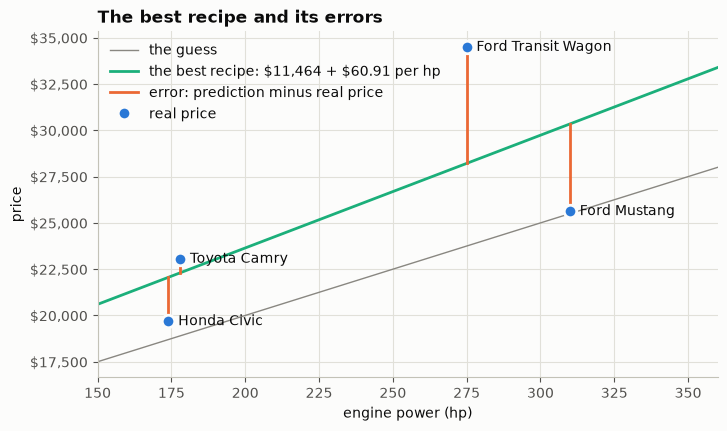

In [7]:
fig, ax = plt.subplots()
ax.plot(hp_range, bias + weight * hp_range, color=GREY, linewidth=1, label='the guess')
ax.plot(hp_range, w_best[0] + w_best[1] * hp_range, color=GREEN,
        label=rf'the best recipe: \${w_best[0]:,.0f} + \${w_best[1]:.2f} per hp')
for engine_hp, price, error in zip(cars.engine_hp, y, errors):
    ax.plot([engine_hp] * 2, [price, price + error], color=ORANGE, linewidth=2)
ax.plot([], [], color=ORANGE, label='error: prediction minus real price')
draw_cars(ax)
ax.set_title('The best recipe and its errors')
ax.legend(loc='upper left')
plt.show()

**Reading the chart.** The green line is the best recipe, and the thin grey one is the guess from section 1, for comparison. The best line runs through the middle of the four cars, with two of them above it and two below, so the errors balance out: that's what "the errors add up to 0" looks like. It's also steeper than the guess (\$60.91 per hp instead of \$50). Tilted any other way, the line would leave errors that grow or shrink with horsepower.

Both sums are 0, up to rounding (`1e-12` means 0.000000000001). Those two zeros are what make these weights the best:

- **The errors add up to 0.** If they added up to, say, +\$5,000, the predictions would be too high on average, and lowering the bias would improve the score.
- **The errors are unrelated to horsepower.** If the high-horsepower cars tended to have positive errors, tilting the recipe (a smaller weight per horsepower) would improve the score.

In general: at the best weights, the errors have no pattern left that any single column could fix. That is one condition per column, and together those conditions pin the weights down. Section 11 turns this sentence into an equation.

### 3. Why we predict the log of the price

Prices in the data run from \$2,000 to \$2,065,902. With dollars as the target, a \$100,000 error on one supercar would outweigh hundreds of small errors on ordinary cars. So the notebooks predict $\log(1 + \text{price})$ instead, and that changes what a weight means.

On the log scale, adding $w$ to a prediction multiplies the predicted price by $e^w$. So a weight is a *percentage*, and an error is a *ratio*. An error of 0.1 means about 10% too high, whether the car costs \$20,000 or \$2,000,000, so every car counts equally.

In [8]:
# e^w - 1 is the percentage change; np.expm1(w) computes it accurately.
print(f"weight  0.0331: price × {np.exp(0.0331):.4f}, i.e. {np.expm1(0.0331):+.1%}   (the 2-door weight in the other notebooks)")
print(f"weight -0.1:    price × {np.exp(-0.1):.4f}, i.e. {np.expm1(-0.1):+.1%}")
print(f"an error of ±0.45 on the log scale: the price is off by a factor of {np.exp(0.45):.2f} or {np.exp(-0.45):.2f}")

weight  0.0331: price × 1.0337, i.e. +3.4%   (the 2-door weight in the other notebooks)
weight -0.1:    price × 0.9048, i.e. -9.5%
an error of ±0.45 on the log scale: the price is off by a factor of 1.57 or 0.64


For small weights, the weight itself is close to the percentage: 0.0331 is about 3.3%, and exactly +3.4%.

### 4. Categories become 0/1 columns

A door count is a label, not a quantity (section 5 of the NumPy notebook explains why), so each door count gets its own column: 1 if the car has that many doors, 0 otherwise.

In [9]:
doors = pd.DataFrame({
    'bias':        [1, 1, 1, 1],
    'has_2_doors': [1, 0, 0, 0],
    'has_3_doors': [0, 1, 0, 0],
    'has_4_doors': [0, 0, 1, 1],
    'price':       cars.price.to_numpy(),
}, index=cars.car)
doors

,bias,has_2_doors,has_3_doors,has_4_doors,price
car,,,,,
Ford Mustang,1,1,0,0,25645
Ford Transit Wagon,1,0,1,0,34515
Honda Civic,1,0,0,1,19700
Toyota Camry,1,0,0,1,23070


With only these columns, the recipe is: prediction = bias + the weight of the car's door column. Every car picks up exactly one door weight.

### 5. The slide: when the best weights are not unique

Here are two very different sets of weights, written as (bias, has_2, has_3, has_4):

In [10]:
D = doors[['bias', 'has_2_doors', 'has_3_doors', 'has_4_doors']].to_numpy(dtype=float)

weights_A = np.array([21385, 4260, 13130, 0])
weights_B = np.array([100000, -74355, -65485, -78615])

print('predictions with A:', D @ weights_A)
print('predictions with B:', D @ weights_B)

predictions with A: [25645. 34515. 21385. 21385.]
predictions with B: [25645. 34515. 21385. 21385.]


They give identical predictions, to the dollar. (Neither predicts the Civic and the Camry exactly: this model sees them as identical cars, so the best it can do is their average, \$21,385.)

B is A with \$78,615 added to the bias and \$78,615 subtracted from every door weight. Each car gets the bias plus exactly one door weight, so for every car the two changes cancel. That works with any amount, not just \$78,615. Call it **the slide**. So there are infinitely many best answers, and no way to say which door weight is *the* door weight.

The cause is a recipe. For every car,

`has_2_doors + has_3_doors + has_4_doors = 1 = bias`

so the bias column can be rebuilt exactly from the door columns. That is the whole problem, in its general form:

> **No column may be an exact recipe of the other columns.** If one is, there are infinitely many best weights.

In the NumPy notebook, 6 cars with an unknown door count (filled in as 0) accidentally prevented this. A car with 0 in all three door columns breaks the recipe: for it, the door columns add up to 0, not 1. Let's add one of those 6 cars, a Tesla Model S.

In [11]:
# The Tesla (2016, $79,500) has 0 in all three door columns.
D_tesla = np.vstack([D, [1, 0, 0, 0]])
y_tesla = np.append(y, 79500)

print('A predicts the Tesla at', D_tesla[-1] @ weights_A)
print('B predicts the Tesla at', D_tesla[-1] @ weights_B)

w_unique = np.linalg.solve(D_tesla.T @ D_tesla, D_tesla.T @ y_tesla)
print('the one best answer with the Tesla:', w_unique)

A predicts the Tesla at 21385.0
B predicts the Tesla at 100000.0
the one best answer with the Tesla: [ 79500. -53855. -44985. -58115.]


The Tesla notices the slide: A and B disagree about it, so they can't both be best. As the only car with no door weight, it fixes the bias at its own price, \$79,500, and every door weight becomes "how much less than the Tesla". That's one unique answer, but a strange one: it rests entirely on a car whose door count nobody knows. That's why the NumPy notebook removed those cars and fixed the model properly (section 8).

### 6. Three disguises of the same problem

The NumPy notebook ran into the rule three times. The doors were the obvious case. The other two:

**`popularity`.** Popularity is one number per brand: every BMW has 3916 and every Chevrolet has 1385. Once the model also has a column per make, popularity can be rebuilt from those columns. With just these two makes,

popularity = 1385 × bias + 2531 × make_is_bmw

A BMW gets 1385 + 2531 = 3916, and a Chevrolet gets 1385.

In [12]:
brands = pd.DataFrame({
    'bias':        [1, 1, 1, 1],
    'popularity':  [3916, 3916, 1385, 1385],
    'make_is_bmw': [1, 1, 0, 0],
}, index=['bmw', 'bmw', 'chevrolet', 'chevrolet'])

rebuilt = 1385 * brands.bias + 2531 * brands.make_is_bmw
print('rebuilt popularity:', rebuilt.to_numpy())
print('real popularity:   ', brands.popularity.to_numpy())

rebuilt popularity: [3916 3916 1385 1385]
real popularity:    [3916 3916 1385 1385]


It's the same slide in a different disguise: raise the popularity weight by 1, lower the bias by 1,385 and the BMW weight by 2,531, and no prediction changes.

**An all-zero column.** On some random splits, a rare make (there are only 3 Genesis cars in the whole dataset) ended up with no cars at all in the training set, so its column was 0 for every training car. That column's weight is multiplied by 0 for every car, so it could be anything: 0, 1,000 or −1,000,000 all give the same predictions. It's the simplest recipe of all: 0 × anything.

### 7. Why the computer didn't complain

If there are infinitely many best answers, a formula that promises *the* answer ought to fail. The NumPy notebook's formula contains a matrix inverse, the matrix version of dividing, and here it would have to divide by zero. So why did NumPy return numbers instead of an error?

Because computers round. They keep about 16 significant digits, and most decimal numbers can't be stored exactly:

In [13]:
print(0.1 + 0.2 == 0.3)
print(0.1 + 0.2)

False
0.30000000000000004


When a calculation that should end at exactly 0 ends at 0.00000000000000044 instead, dividing by it doesn't raise an error. It produces a huge number. On our four cars:

In [14]:
# The NumPy notebook's formula, w = (X^T X)^(-1) X^T y, on the four cars and their door columns.
w_inv = np.linalg.inv(D.T @ D) @ D.T @ y
print('weights from inv:', w_inv)
print('predictions:     ', D @ w_inv)
print('real prices:     ', y)

# The number inv effectively divides by (the determinant, section 13) should be exactly 0:
print()
print('determinant:     ', np.linalg.det(D.T @ D))
print(f'condition number: {np.linalg.cond(D.T @ D):.1e}')

weights from inv: [34515.  -8870.  34515.   4127.5]
predictions:      [25645.  69030.  38642.5 38642.5]
real prices:      [25645. 34515. 19700. 23070.]

determinant:      4.440892098500646e-16
condition number: 2.1e+17


No error, just confident nonsense: the Transit is predicted at \$69,030, twice its real price. These weights aren't even one of the infinitely many best answers. Rounding broke them in a way that no slide can explain. On the real data, the same thing produced the RMSE of 16.5.

The **condition number** measures how close a calculation is to this situation: roughly, how many times rounding errors can be magnified. As a rule of thumb, a condition number of $10^k$ can cost $k$ of the 16 digits. Here it is about $10^{17}$, so every digit is lost.

### 8. Three ways out

**1. Drop a column.** If a car is neither 2-door nor 3-door, it must be 4-door, so `has_4_doors` adds nothing. Without it, the recipe is gone and there is exactly one best answer:

In [15]:
D_drop = D[:, :3]    # bias, has_2_doors, has_3_doors
w_drop = np.linalg.solve(D_drop.T @ D_drop, D_drop.T @ y)
print('bias, has_2, has_3:', w_drop)

bias, has_2, has_3: [21385.  4260. 13130.]


These are weights A. The bias is now the price of a 4-door car (the **reference** category), and each door weight is a difference: a 2-door car costs \$4,260 more than a comparable 4-door car, and a 3-door car \$13,130 more. Differences were all the data could ever tell us.

**2. Pick the smallest weights.** Keep every column and, out of the infinitely many best answers, return the one with the smallest weights (smallest sum of squared weights). That's what `np.linalg.lstsq` and scikit-learn's `LinearRegression` do.

In [16]:
w_small = np.linalg.lstsq(D, y, rcond=None)[0]
print('smallest best weights:', w_small)
print('predictions:          ', D @ w_small)
print('bias minus the sum of the door weights:', round(w_small[0] - w_small[1:].sum(), 6))

# Slide away from it in either direction: the predictions stay, the weights grow.
slide = np.array([1, -1, -1, -1])
print()
for t in [-1000, 0, 1000]:
    w_slid = w_small + t * slide
    print(f'slide {t:+5}: predictions {D @ w_slid}, sum of squared weights {np.sum(w_slid ** 2):,.0f}')

smallest best weights: [20386.25  5258.75 14128.75   998.75]
predictions:           [25645. 34515. 21385. 21385.]
bias minus the sum of the door weights: 0.0

slide -1000: predictions [25645. 34515. 21385. 21385.], sum of squared weights 647,872,719
slide    +0: predictions [25645. 34515. 21385. 21385.], sum of squared weights 643,872,719
slide +1000: predictions [25645. 34515. 21385. 21385.], sum of squared weights 647,872,719


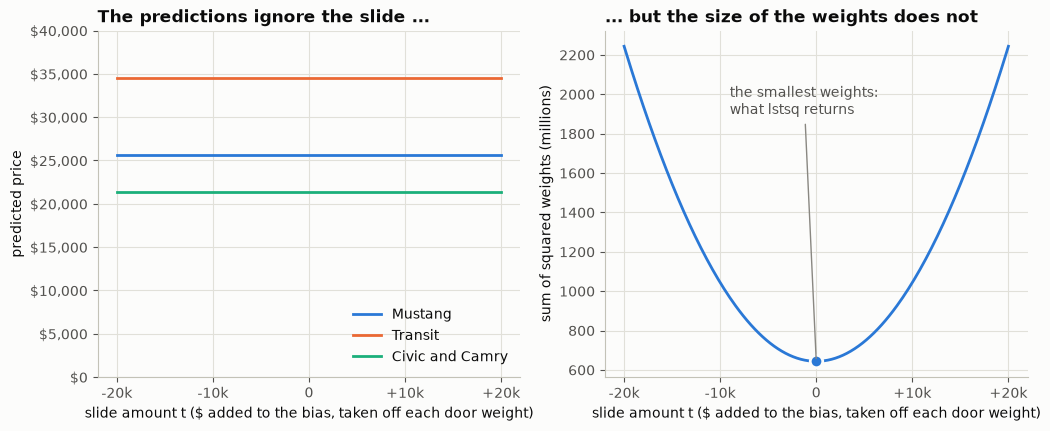

In [17]:
t_values = np.linspace(-20000, 20000, 201)
slid = np.array([w_small + t * slide for t in t_values])     # one row of weights per slide amount

fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.5))
for row, label, color in [(0, 'Mustang', BLUE), (1, 'Transit', ORANGE), (2, 'Civic and Camry', GREEN)]:
    left.plot(t_values, slid @ D[row], color=color, label=label)
left.set_title('The predictions ignore the slide ...')
left.set_xlabel('slide amount t ($ added to the bias, taken off each door weight)')
left.set_ylabel('predicted price')
left.yaxis.set_major_formatter(lambda value, _: f'${value:,.0f}')
left.set_ylim(0, 40000)
left.legend(loc='lower right')
for ax in (left, right):
    ax.set_xticks([-20000, -10000, 0, 10000, 20000])
    ax.xaxis.set_major_formatter(lambda value, _: f'{value / 1000:+,.0f}k' if value else '0')

right.plot(t_values, (slid ** 2).sum(axis=1) / 1e6, color=BLUE)
right.plot(0, (w_small ** 2).sum() / 1e6, 'o', color=BLUE, markersize=9, markeredgecolor=BACKGROUND, markeredgewidth=2)
right.annotate('the smallest weights:\nwhat lstsq returns', xy=(0, (w_small ** 2).sum() / 1e6), xytext=(-9000, 1900),
               arrowprops=dict(arrowstyle='-', color=GREY), color='#52514e')
right.set_title('... but the size of the weights does not')
right.set_xlabel('slide amount t ($ added to the bias, taken off each door weight)')
right.set_ylabel('sum of squared weights (millions)')
plt.show()

**Reading the chart.** Both panels have the slide amount t on the horizontal axis: t dollars added to the bias and taken off each of the three door weights, starting from the smallest weights at t = 0. On the left is each car's predicted price: three flat lines, because no slide changes any prediction. On the right is the sum of squared weights: a parabola with its lowest point at t = 0. Among all the equally good answers, `lstsq` returns the one at the bottom of this parabola.

The same best predictions, plus a fingerprint: the bias equals the sum of the three door weights. Sliding moves the bias one way and all three door weights the other way, and the sum of squared weights is smallest exactly where the bias balances the three door weights. Section 14 proves it.

scikit-learn's answer looks different, with door weights that add up to 0, because it doesn't count the bias among the weights it keeps small. It's the same idea with different bookkeeping, and section 14 explains that too.

**3. Ridge regression.** Add a penalty for large weights to the score:

sum of squared errors + r × (sum of squared weights)

Now the slide is no longer free, because it changes the penalty, so there is always exactly one best answer. For a small `r` the predictions barely change. A large `r` pulls every weight toward 0, which pulls every prediction toward the average price.

In [18]:
for r in [0.0001, 1, 10]:
    penalty = r * np.eye(4)
    penalty[0, 0] = 0          # the bias is not penalised, as in the NumPy notebook
    w_ridge = np.linalg.solve(D.T @ D + penalty, D.T @ y)
    print(f'r = {r:<7} weights {w_ridge.round(1)}   predictions {(D @ w_ridge).round()}')

r = 0.0001  weights [27181.6 -1536.4  7332.7 -5796.3]   predictions [25645. 34514. 21385. 21385.]
r = 1       weights [26602.   -478.5  3956.5 -3478. ]   predictions [26124. 30558. 23124. 23124.]
r = 10      weights [25921.5   -25.1   781.2  -756.1]   predictions [25896. 26703. 25165. 25165.]


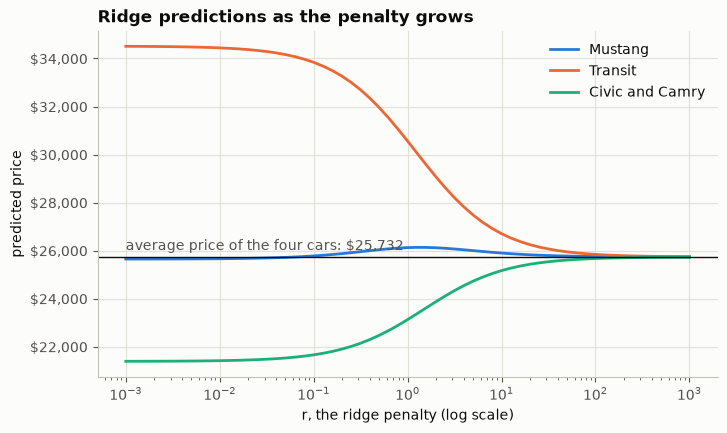

In [19]:
r_grid = np.logspace(-3, 3, 61)
ridge_predictions = []
for r in r_grid:
    penalty = r * np.eye(4)
    penalty[0, 0] = 0
    ridge_predictions.append(D @ np.linalg.solve(D.T @ D + penalty, D.T @ y))
ridge_predictions = np.array(ridge_predictions)

fig, ax = plt.subplots()
for row, label, color in [(0, 'Mustang', BLUE), (1, 'Transit', ORANGE), (2, 'Civic and Camry', GREEN)]:
    ax.plot(r_grid, ridge_predictions[:, row], color=color, label=label)
ax.axhline(y.mean(), color=INK, linewidth=1)
ax.annotate(f'average price of the four cars: ${y.mean():,.0f}', xy=(1e-3, y.mean()), xytext=(0, 5),
            textcoords='offset points', color='#52514e')
ax.set_xscale('log')
ax.set_title('Ridge predictions as the penalty grows')
ax.set_xlabel('r, the ridge penalty (log scale)')
ax.set_ylabel('predicted price')
ax.yaxis.set_major_formatter(lambda value, _: f'${value:,.0f}')
ax.legend(loc='upper right')
plt.show()

**Reading the chart.** The horizontal axis is the ridge penalty r (log scale), and the vertical axis is the predicted price. At the far left, with a tiny r, the predictions are the best ones from before: \$34,515 for the Transit, \$25,645 for the Mustang, and \$21,385 (their average) for the Civic and the Camry. As r grows, the door weights are pushed toward 0 and every prediction slides toward the black line, the average price of the four cars. The Transit moves the most, because its prediction started furthest from the average.

With a tiny `r`, ridge gives the best predictions again, and since the bias isn't penalised, it lands on scikit-learn's version of "smallest": the three door weights add up to 0.

Why would we *want* weights pulled toward 0? Because some weights are fitted on very few cars. The Transit is the only 3-door car here, so the 3-door weight is learned from a single car. In the NumPy notebook, the Bugatti weight was fitted on 3 cars and claimed that a Bugatti is 999% more expensive than a comparable Chevrolet. Ridge says: unless the data insists, assume a category is close to average. Section 16 shows that categories with fewer cars get pulled harder.

### 9. Why step-by-step solvers need rescaled columns

The formula in section 2 finds the weights in one go. Some solvers, like the `'sag'` solver that gave up in the scikit-learn notebook, work step by step instead: start with all weights at 0, check which way the score goes down, take a small step that way, and repeat. This is **gradient descent**. (The gradient is the direction in which the score rises fastest; each step goes the opposite way.)

Picture the score as a landscape over all possible (bias, weight) pairs, with the best weights at the lowest point. The steps have to be small enough not to overshoot in the steepest direction. If the valley is steep in one direction and nearly flat in another, those small steps crawl along the flat direction almost forever. Columns on very different scales produce exactly that: changing the horsepower weight by 1 moves every prediction by hundreds of dollars, while changing the bias by 1 moves it by one dollar.

Let's run gradient descent on the horsepower model of section 2 three times: with horsepower as it is, divided by 100, and **standardised** (subtract the column's mean, then divide by its standard deviation, so that it is centred at 0 with a typical size of 1).

In [20]:
def gradient_descent(X, y, steps):
    # The largest step size that is guaranteed not to overshoot (section 17 explains where it comes from).
    step_size = 1 / np.linalg.eigvalsh(X.T @ X).max()
    w = np.zeros(X.shape[1])
    for _ in range(steps):
        w = w - step_size * (X.T @ (X @ w - y))   # one step against the gradient
    return w


hp = cars.engine_hp.to_numpy(dtype=float)
versions = {
    'horsepower as it is': hp,
    'horsepower / 100': hp / 100,
    'standardised': (hp - hp.mean()) / hp.std(),
}

for name, column in versions.items():
    Xv = np.column_stack([np.ones(4), column])
    best = np.linalg.solve(Xv.T @ Xv, Xv.T @ y)
    for steps in [10, 1000]:
        w = gradient_descent(Xv, y, steps)
        excess = ((Xv @ w - y) ** 2).sum() / ((Xv @ best - y) ** 2).sum() - 1
        print(f'{name:20s} {steps:>5} steps: score {excess:7.2%} above the best')

horsepower as it is     10 steps: score  46.98% above the best
horsepower as it is   1000 steps: score  46.88% above the best
horsepower / 100        10 steps: score  18.34% above the best
horsepower / 100      1000 steps: score   0.00% above the best
standardised            10 steps: score   0.00% above the best
standardised          1000 steps: score   0.00% above the best


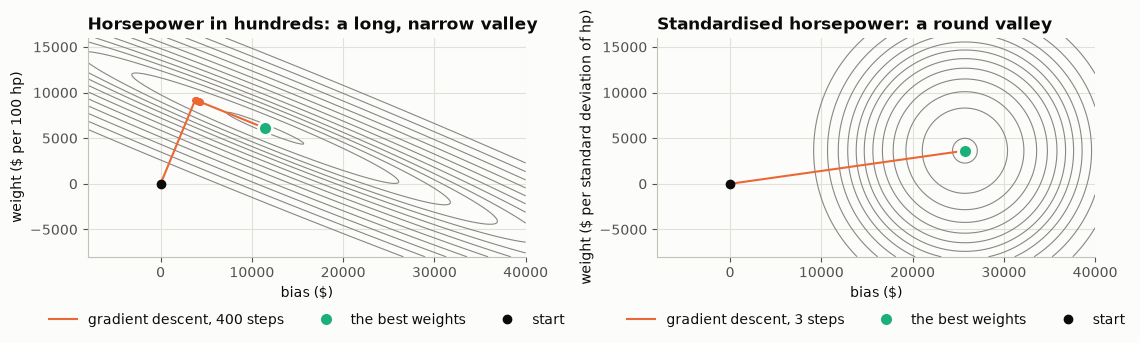

In [21]:
def descent_path(X, y, steps):
    # All the weights gradient descent visits, starting from 0.
    step_size = 1 / np.linalg.eigvalsh(X.T @ X).max()
    path = [np.zeros(X.shape[1])]
    for _ in range(steps):
        path.append(path[-1] - step_size * (X.T @ (X @ path[-1] - y)))
    return np.array(path)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={'wspace': 0.3})
panels = [('horsepower / 100', 'weight ($ per 100 hp)', 400, 'Horsepower in hundreds: a long, narrow valley'),
          ('standardised', 'weight ($ per standard deviation of hp)', 3, 'Standardised horsepower: a round valley')]
for ax, (name, ylabel, steps, title) in zip(axes, panels):
    Xv = np.column_stack([np.ones(4), versions[name]])
    best = np.linalg.solve(Xv.T @ Xv, Xv.T @ y)
    path = descent_path(Xv, y, steps)

    # The score over a grid of (bias, weight) pairs, drawn as contour lines: each line joins equal scores.
    b_grid, w_grid = np.meshgrid(np.linspace(-8000, 40000, 300), np.linspace(-8000, 16000, 300))
    score = sum((b_grid + w_grid * x - price) ** 2 for x, price in zip(Xv[:, 1], y))
    ax.contour(b_grid, w_grid, score, levels=np.quantile(score, np.linspace(0.005, 0.6, 12)), colors=GREY,
               linewidths=0.8)
    ax.plot(path[:, 0], path[:, 1], '-', color=ORANGE, linewidth=1.5, label=f'gradient descent, {steps} steps')
    ax.plot(path[:12, 0], path[:12, 1], 'o', color=ORANGE, markersize=4)
    ax.plot(*best, 'o', color=GREEN, markersize=10, markeredgecolor=BACKGROUND, markeredgewidth=2, label='the best weights')
    ax.plot(0, 0, 'o', color=INK, markersize=6, label='start')
    ax.set_title(title)
    ax.set_xlabel('bias ($)')
    ax.set_ylabel(ylabel)
    ax.set_aspect('equal')
    ax.set_xlim(-8000, 40000)
    ax.set_ylim(-8000, 16000)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncols=3)
plt.show()

**Reading the chart.** Each panel is a map of all possible (bias, weight) pairs, with the bias on the horizontal axis and the weight on the vertical axis, both in dollars and drawn to the same scale. Each grey contour line joins pairs with the same score, like the height lines on a hiking map, and the green dot is the lowest point. The orange line is the path gradient descent takes from the black starting dot.

With horsepower in hundreds (left), the contours are long, thin ellipses: a narrow valley. The first step shoots across the valley, and every step after that crawls along the valley floor; it takes about 350 steps to get close to the bottom (section 17 counts them exactly). Standardised (right), the contours are circles. The steepest way down points straight at the bottom, and the first step lands on it.

With raw horsepower, 1,000 steps achieve almost nothing: the score is still 47% above the best. Divided by 100, the same solver gets there within 1,000 steps. Standardised, it's there after 10 (section 17 shows it's actually after 1). The data and the model are the same in all three runs; only the units of one column changed. That's why `'sag'` converged in the scikit-learn notebook as soon as the columns were rescaled.

## Part II: The same ideas in linear algebra

Part II revisits each idea of Part I, and replaces the four toy cars with the real training data wherever that makes the point better.

### 10. Notation, and the real data

- There are $n$ cars (rows) and $p$ columns. The **design matrix** $X \in \mathbb{R}^{n \times p}$ has one row per car and one column per feature, including the column of 1's for the bias.
- $y \in \mathbb{R}^n$ holds the targets (log prices), and $w \in \mathbb{R}^p$ the weights.
- The predictions for all cars at once are $\hat y = Xw$. The model is **linear in $w$**: $X(aw + bv) = aXw + bXv$. Almost everything below follows from that one line.

The next cell prepares the data exactly as the other two notebooks do (same cleaning, same split with seed 0), with a shortened `dataflow`. `design(df, columns)` builds a design matrix, with the column of 1's in front.

In [22]:
import random

df = pd.read_csv('data.csv')
df.columns = df.columns.str.lower().str.replace(' ', '_')
for col in [c for c in df.columns if pd.api.types.is_string_dtype(df[c])]:
    df[col] = df[col].str.lower()
df['msrp_log'] = np.log1p(df.msrp)
df = df.fillna(0)
df['car_age'] = df.year.max() - df.year
for n in (2, 3, 4):
    df[f'has_{n}_doors'] = (df.number_of_doors == n).astype(int)
all_makes = sorted(df.make.unique())
for make in all_makes:
    df[f'make_is_{make}'] = (df.make == make).astype(int)
df_corrected = df[df.number_of_doors != 0]     # without the 6 cars whose door count was missing


def dataflow(df, seed=0):
    # The same 60/20/20 split as the other notebooks; only train and validation are needed here.
    n = len(df)
    order = random.Random(seed).sample(range(n), n)
    n_train, n_valid = int(0.6 * n), int(0.2 * n)
    return df.iloc[order[:n_train]], df.iloc[order[n_train:n_train + n_valid]]


def design(df, columns):
    # A column of 1's for the bias, then the given columns.
    return np.column_stack([np.ones(len(df)), df[columns].to_numpy(dtype=float)])


base = ['engine_hp', 'highway_mpg', 'city_mpg', 'popularity']
make_columns = [f'make_is_{make}' for make in all_makes if make != 'chevrolet']

df_train, df_valid = dataflow(df)
train_c, valid_c = dataflow(df_corrected)
print(len(df_train), 'training cars;', len(train_c), 'after removing the 6')

7148 training cars; 7144 after removing the 6


### 11. Least squares is a projection

*Formalises section 2.*

**The problem.** Find $w$ that minimises the sum of squared errors

$$L(w) = \lVert y - Xw \rVert^2 = \sum_{i=1}^{n} \big(y_i - (Xw)_i\big)^2 .$$

**The normal equations.** Expanding the square,

$$L(w) = y^T y - 2\, w^T X^T y + w^T X^T X\, w ,$$

and setting the gradient to zero gives

$$\nabla L(w) = -2\, X^T (y - Xw) = 0 \quad\Longleftrightarrow\quad X^T X\, w = X^T y .$$

These are the **normal equations**. Because $w^T X^T X\, w = \lVert Xw \rVert^2 \ge 0$, $L$ is convex (bowl-shaped): every solution of the normal equations is a minimum, and every minimum is a solution. When $X^T X$ is invertible, the solution is the NumPy notebook's formula $w = (X^T X)^{-1} X^T y$.

**Section 2, formally.** Write $r = y - Xw$ for the vector of errors, the **residual**. The normal equations say exactly $X^T r = 0$: the residual is **orthogonal** to every column of $X$. Entry $j$ of $X^T r$ is (column $j$) $\cdot\, r$. For the bias column of 1's that is the sum of the errors; for `engine_hp` it is the sum of error × horsepower. Those are the two sums that came out as 0 in section 2: "no pattern left that any single column could fix".

**The geometry.** As $w$ ranges over $\mathbb{R}^p$, $Xw$ ranges over all combinations of the columns of $X$: the **column space** $C(X)$, a flat subspace of $\mathbb{R}^n$. Every prediction the model can make lives in $C(X)$, and minimising $\lVert y - Xw \rVert$ means finding the point of $C(X)$ closest to $y$. That point is the **orthogonal projection** $\hat y$ of $y$ onto $C(X)$, the foot of the perpendicular from $y$, and it is characterised by $y - \hat y \perp C(X)$: once again, $X^T r = 0$.

One consequence is needed in section 15: **the best predictions $\hat y$ depend only on the column space $C(X)$**, not on which particular columns span it.

Here is the orthogonality on the real data, for the base-feature model of section 3 of the other notebooks. (`np.linalg.solve` solves the normal equations without forming the inverse: the same answer, computed more accurately.)

In [23]:
X = design(df_train, base)
y = df_train.msrp_log.to_numpy()

w = np.linalg.solve(X.T @ X, X.T @ y)
residual = y - X @ w

print('X^T r =', X.T @ residual)
print(f'for scale, the largest entry of X^T y is {np.abs(X.T @ y).max():.1e}')

rmse = np.sqrt(np.mean((df_valid.msrp_log - design(df_valid, base) @ w) ** 2))
print('validation RMSE:', rmse)

X^T r = [ 0.          0.          0.         -0.          0.00000002]
for scale, the largest entry of X^T y is 1.1e+08
validation RMSE: 0.7734149758173141


$X^T r$ is 0 to within rounding, and the validation RMSE is the familiar 0.7734.

**A picture of the projection.** The space $\mathbb{R}^n$ has one axis per car, so with $n = 11{,}908$ it can't be drawn. With two cars it can. Take the Mustang and the Civic, and a model with one column and no bias: price $= w \times$ engine_hp. A point in the plane below is a pair of prices (Mustang, Civic). The column space is every pair the model can produce, $w \times (310, 174)$: a line through the origin.

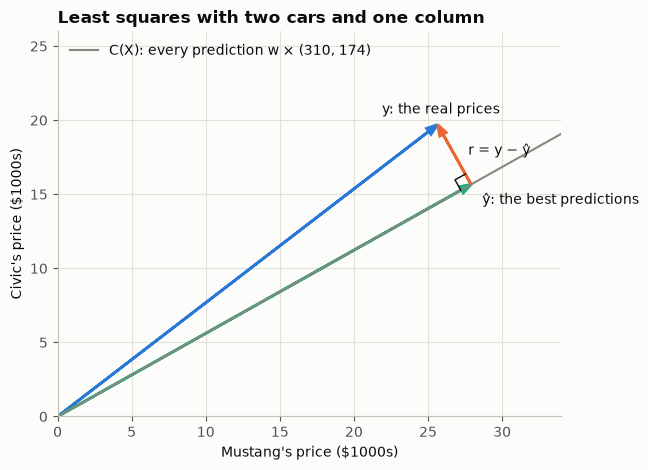

w = 90.03 dollars per hp;  r · x = -1.1e-12


In [24]:
y_two = np.array([25.645, 19.700])      # real prices of the Mustang and the Civic, in $1000s
x_two = np.array([310, 174])            # their horsepower: the model's only column
w_two = (x_two @ y_two) / (x_two @ x_two)
y_hat = w_two * x_two                   # the projection of y onto the line
r_two = y_two - y_hat

fig, ax = plt.subplots(figsize=(6.5, 6.5))
t = np.linspace(0, 0.11, 2)
ax.plot(t * x_two[0], t * x_two[1], color=GREY, linewidth=1.5, label='C(X): every prediction w × (310, 174)')
arrow = dict(length_includes_head=True, head_width=0.5, linewidth=2)
ax.arrow(0, 0, *y_two, color=BLUE, **arrow)
ax.arrow(0, 0, *y_hat, color=GREEN, **arrow)
ax.arrow(*y_hat, *r_two, color=ORANGE, **arrow)
ax.annotate('y: the real prices', y_two, xytext=(-40, 8), textcoords='offset points')
ax.annotate('ŷ: the best predictions', y_hat, xytext=(8, -14), textcoords='offset points')
ax.annotate('r = y − ŷ', (y_hat + y_two) / 2, xytext=(10, 0), textcoords='offset points')

# a small square marking the right angle at ŷ
u, v = x_two / np.linalg.norm(x_two), r_two / np.linalg.norm(r_two)
corner = np.array([y_hat - 0.8 * u, y_hat - 0.8 * u + 0.8 * v, y_hat + 0.8 * v])
ax.plot(corner[:, 0], corner[:, 1], color=INK, linewidth=1)

ax.set_aspect('equal')
ax.set_xlim(0, 34)
ax.set_ylim(0, 26)
ax.set_xlabel("Mustang's price ($1000s)")
ax.set_ylabel("Civic's price ($1000s)")
ax.set_title('Least squares with two cars and one column')
ax.legend(loc='upper left')
plt.show()

print(f'w = {w_two * 1000:.2f} dollars per hp;  r · x = {r_two @ x_two:.1e}')

**Reading the chart.** Both axes are prices in thousands of dollars: the horizontal one for the Mustang and the vertical one for the Civic, so a single point is a pair of prices. The blue arrow is $y$, the real prices (25.6, 19.7). The grey line is every pair of predictions this model can make. The green arrow $\hat y$ ends at the point of that line closest to $y$, and the orange arrow $r = y - \hat y$ (the errors) meets the line at a right angle, marked by the small square: $r \cdot x = 0$ up to rounding. Moving along the grey line from $\hat y$ in either direction would only make the distance to $y$ longer (Pythagoras again).

With 11,908 cars, the same picture has 11,908 axes and the column space has several dimensions, but the right angle is exactly the same: $X^T r = 0$.

### 12. Uniqueness: rank and null space

*Formalises sections 5 and 6.*

**Definitions.** The columns of $X$ are **linearly dependent** if $Xv = 0$ for some vector $v \neq 0$, that is, if some combination of the columns (not all coefficients zero) is the zero vector. Equivalently, some column is a combination of the others: Part I's "exact recipe". The set of all such $v$ (together with $0$) is the **null space** $N(X) = \{v : Xv = 0\}$. The **rank** of $X$ is its number of linearly independent columns, and $\operatorname{rank} X = p - \dim N(X)$.

**Theorem.** The following are equivalent:

1. the least-squares solution is unique;
2. $N(X) = \{0\}$, i.e. no column is a recipe of the others;
3. $\operatorname{rank} X = p$;
4. $X^T X$ is invertible.

*Proof.* (2 ⇔ 3) is the rank formula above.
(2 ⇔ 4): $N(X^T X) = N(X)$. If $Xv = 0$ then $X^T X v = 0$. Conversely, if $X^T X v = 0$ then $0 = v^T X^T X v = \lVert Xv \rVert^2$, so $Xv = 0$. And a square matrix is invertible exactly when its null space is $\{0\}$.
(1 ⇔ 2): If $v \in N(X)$, then $X(w + tv) = Xw + t\,Xv = Xw$ for every number $t$, so whenever $w$ is a solution, so is every $w + tv$. This is **the slide** of section 5, and $N(X)$ is the set of all the directions one can slide in. If instead $N(X) = \{0\}$, the normal equations have the invertible matrix $X^T X$ and exactly one solution. ∎

So the set of all best weights is $w_0 + N(X)$: any one solution plus the whole null space. They all give the same predictions: the projection $\hat y$ is unique even when $w$ is not.

**The three disguises as null vectors.** Write $e_j$ for the vector with a 1 in position $j$ and 0 elsewhere. In the order of section 6:

- doors: $v = e_{\text{bias}} - e_{\text{has\_2}} - e_{\text{has\_3}} - e_{\text{has\_4}}$, because bias − has_2 − has_3 − has_4 = 0 for every car;
- `popularity`, with 47 make columns and chevrolet as the reference: $v = e_{\text{popularity}} - 1385\, e_{\text{bias}} - \sum_{m} (\text{pop}_m - 1385)\, e_{\text{make\_is\_}m}$, where $\text{pop}_m$ is make $m$'s popularity;
- an all-zero column $j$: $v = e_j$.

We don't have to guess these. The **singular value decomposition** (SVD, section 13) finds the null space automatically. Here it is on the real door-trap matrix, the model of section 6 of the other notebooks, trained on `df_corrected`:

In [25]:
door_trap = base + ['car_age', 'has_2_doors', 'has_3_doors', 'has_4_doors']
X3 = design(train_c, door_trap)
y3 = train_c.msrp_log.to_numpy()

U, s, Vt = np.linalg.svd(X3, full_matrices=False)
print('singular values:', s)
print('rank:', np.linalg.matrix_rank(X3), 'of', X3.shape[1], 'columns')

# The right singular vector of the zero singular value spans the null space. Scale it so its bias entry is 1:
null_vector = Vt[-1] / Vt[-1][0]
pd.Series(null_vector, index=['bias'] + door_trap).round(6)

singular values: [178552.89484881  16863.32396219   1696.37425578    698.26926813    294.53372997     51.77646177     17.81483205
     13.82681283      0.        ]
rank: 8 of 9 columns


bias           1.0
engine_hp     -0.0
highway_mpg    0.0
city_mpg      -0.0
popularity    -0.0
car_age       -0.0
has_2_doors   -1.0
has_3_doors   -1.0
has_4_doors   -1.0
dtype: float64

That's exactly $e_{\text{bias}} - e_{\text{has\_2}} - e_{\text{has\_3}} - e_{\text{has\_4}}$: the SVD rediscovered the recipe. Next, `popularity` with the 47 make columns:

In [26]:
pop_trap = base + ['car_age', 'has_2_doors', 'has_3_doors'] + make_columns
XP = design(train_c, pop_trap)
U, s, Vt = np.linalg.svd(XP, full_matrices=False)
print('three smallest singular values:', s[-3:])

# Scale the null vector so that its popularity entry is 1, and compare it with the recipe above.
v = pd.Series(Vt[-1], index=['bias'] + pop_trap)
v = v / v['popularity']
popularity = df_corrected.groupby('make').popularity.first()
shown = ['bmw', 'ford', 'bugatti', 'tesla']

pd.DataFrame({
    'entry of the null vector': v[['bias'] + [f'make_is_{m}' for m in shown]].to_numpy().round(6),
    'predicted by the recipe': [-1385] + [-(popularity[m] - 1385) for m in shown],
}, index=['bias'] + shown)

three smallest singular values: [1.01768598 0.99887783 0.        ]


,entry of the null vector,predicted by the recipe
bias,-1385.0,-1385
bmw,-2531.0,-2531
ford,-4272.0,-4272
bugatti,565.0,565
tesla,-6.0,-6


Each make's entry is minus its popularity (relative to Chevrolet's 1385), to six decimals. The SVD read every brand's popularity off the data without being told that popularity is a brand-level number.

Finally, the all-zero column on the split with seed 20:

In [27]:
make_model = ['engine_hp', 'highway_mpg', 'city_mpg', 'car_age', 'has_2_doors', 'has_3_doors'] + make_columns
train_20, _ = dataflow(df_corrected, seed=20)
XG = design(train_20, make_model)
U, s, Vt = np.linalg.svd(XG, full_matrices=False)

names = ['bias'] + make_model
print('two smallest singular values:', s[-2:])
print('largest entry of the null vector:', names[np.argmax(np.abs(Vt[-1]))], np.abs(Vt[-1]).max())

j = names.index('make_is_genesis')
print(f'row {j} of X^T X is exactly zero:', ((XG.T @ XG)[j] == 0).all())

two smallest singular values: [0.99864797 0.        ]
largest entry of the null vector: make_is_genesis 1.0
row 21 of X^T X is exactly zero: True


The null vector is $e_{\text{make\_is\_genesis}}$. This time the zero is exact: an all-zero column makes the whole matching row of $X^T X$ exactly 0, with no rounding involved, so the elimination inside `np.linalg.inv` meets an exact zero and raises `LinAlgError`. With the doors and `popularity`, rounding turned the zero into a tiny leftover, and `inv` divided by it.

### 13. Why `inv` fails: singular values and the condition number

*Formalises section 7.*

**The SVD.** Every matrix can be written $X = U \Sigma V^T$, where $U \in \mathbb{R}^{n \times p}$ and $V \in \mathbb{R}^{p \times p}$ have orthonormal columns $u_j$ and $v_j$, and $\Sigma = \operatorname{diag}(\sigma_1, \dots, \sigma_p)$ with $\sigma_1 \ge \dots \ge \sigma_p \ge 0$, the **singular values**. Column by column it says $X v_j = \sigma_j u_j$: the unit direction $v_j$ is stretched by the factor $\sigma_j$. A zero singular value means $X v_j = 0$, i.e. $v_j \in N(X)$, which is how section 12 found the recipes. The rank is the number of nonzero singular values.

**The inverse through the SVD.** $X^T X = V \Sigma^2 V^T$, so the eigenvalues of $X^T X$ are the $\sigma_j^2$, and when they are all positive

$$(X^T X)^{-1} = V \Sigma^{-2} V^T, \qquad w = (X^T X)^{-1} X^T y = \sum_{j=1}^{p} \frac{u_j^T y}{\sigma_j}\, v_j .$$

Solving the normal equations means dividing by every $\sigma_j$. When the columns contain a recipe, one $\sigma_j$ is 0 in exact arithmetic but a rounding leftover on a computer, and dividing by it gives the huge meaningless weights of section 7. The determinant, $\det(X^T X) = \prod_j \sigma_j^2$, is 0 in exact arithmetic and just as fragile in floating point: it came out as $4.4 \times 10^{-16}$ in section 7.

**The condition number.** For an invertible matrix $A$, $\kappa(A) = \sigma_{\max}(A) / \sigma_{\min}(A)$ bounds how much a relative error in the data can be magnified in the solution of $Ax = b$. Floating-point numbers carry a relative error of about $\varepsilon \approx 2.2 \times 10^{-16}$, so the computed solution can be off by a relative error of roughly $\kappa \varepsilon$. That is the "$10^k$ costs $k$ digits" rule of thumb. For $X^T X$,

$$\kappa(X^T X) = \frac{\sigma_1^2}{\sigma_p^2} = \kappa(X)^2 :$$

forming $X^T X$ squares the condition number, which is one reason good least-squares solvers (section 14) work with $X$ itself.

In [28]:
print(f'door trap:   cond(X^T X) = {np.linalg.cond(X3.T @ X3):.1e}')

# On a healthy matrix (the fixed model, with 2 door columns), cond(X^T X) = cond(X)^2:
X2 = design(train_c, base + ['car_age', 'has_2_doors', 'has_3_doors'])
print(f'fixed model: cond(X) = {np.linalg.cond(X2):.4e},  cond(X)^2 = {np.linalg.cond(X2) ** 2:.4e},  '
      f'cond(X^T X) = {np.linalg.cond(X2.T @ X2):.4e}')

door trap:   cond(X^T X) = 3.6e+19
fixed model: cond(X) = 1.4268e+04,  cond(X)^2 = 2.0358e+08,  cond(X^T X) = 2.0358e+08


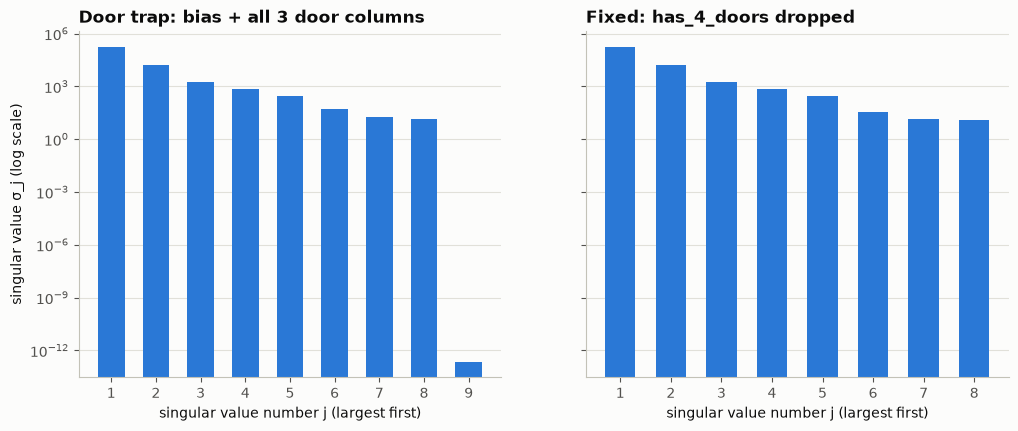

smallest singular value, door trap:   2.2e-13
smallest singular value, fixed model: 12.5


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
panels = [(X3, door_trap, 'Door trap: bias + all 3 door columns'),
          (X2, base + ['car_age', 'has_2_doors', 'has_3_doors'], 'Fixed: has_4_doors dropped')]
for ax, (matrix, columns, title) in zip(axes, panels):
    singular = np.linalg.svd(matrix, compute_uv=False)
    ax.bar(np.arange(1, len(singular) + 1), singular, width=0.6, color=BLUE)
    ax.set_yscale('log')
    ax.set_xticks(np.arange(1, len(singular) + 1))
    ax.set_title(title)
    ax.set_xlabel('singular value number j (largest first)')
    ax.grid(axis='x', visible=False)
axes[0].set_ylabel('singular value σ_j (log scale)')
plt.show()

print(f'smallest singular value, door trap:   {np.linalg.svd(X3, compute_uv=False)[-1]:.1e}')
print(f'smallest singular value, fixed model: {np.linalg.svd(X2, compute_uv=False)[-1]:.1f}')

**Reading the chart.** Each bar is one singular value of a design matrix, from the largest (left) to the smallest (right). The vertical axis is logarithmic: each gridline is 1,000 times the one below. The fixed model's eight singular values run from about $10^5$ down to 12.5. The door trap has eight similar ones, plus a ninth that falls off a cliff to $2.2 \times 10^{-13}$. That ninth one is the recipe `has_2 + has_3 + has_4 = bias`. In exact arithmetic it would be 0, and dividing by it is what gave `inv` its garbage.

For the door trap, $\kappa \varepsilon \approx 3.6 \times 10^{19} \times 2.2 \times 10^{-16}$, several thousand: the possible error is thousands of times larger than the weights themselves, so not one digit of `inv`'s answer can be trusted.

Could the garbage at least be a slide, a correct solution plus some multiple of the null vector? Then the predictions would still be right. Let's split the difference between `inv`'s weights and a correct solution into its part along the null space and the rest:

In [30]:
w_inv = np.linalg.inv(X3.T @ X3) @ X3.T @ y3
w_good = np.linalg.pinv(X3) @ y3                          # a correct solution (section 14)

null_unit = np.linalg.svd(X3, full_matrices=False)[2][-1]  # a unit vector spanning N(X3)
diff = w_inv - w_good
along = (diff @ null_unit) * null_unit
print(f'length of the part along the null space: {np.linalg.norm(along):.1f}')
print(f'length of the rest:                     {np.linalg.norm(diff - along):.1f}')

X3_valid = design(valid_c, door_trap)
y3_valid = valid_c.msrp_log.to_numpy()
for name, weights in [('inv', w_inv), ('pinv', w_good)]:
    print(f'{name:5s} validation RMSE: {np.sqrt(np.mean((y3_valid - X3_valid @ weights) ** 2)):.4f}')

length of the part along the null space: 27.5
length of the rest:                     93.7
inv   validation RMSE: 16.5354
pinv  validation RMSE: 0.5143


Most of the damage is *not* along the null space. Once $\kappa \varepsilon$ is larger than 1, rounding errors can land in every direction, which is why the predictions were wrong (RMSE 16.5), not just the individual weights.

### 14. What `lstsq` returns: the pseudoinverse

*Formalises "pick the smallest weights" from section 8.*

**Definition.** The **Moore–Penrose pseudoinverse** of $X = U \Sigma V^T$ is $X^+ = V \Sigma^+ U^T$, where $\Sigma^+$ inverts the nonzero singular values and leaves the zero ones at 0:

$$w^+ = X^+ y = \sum_{j \,:\, \sigma_j > 0} \frac{u_j^T y}{\sigma_j}\, v_j .$$

In floating point, "nonzero" means "above a small tolerance relative to $\sigma_1$", and the number of singular values above it is scikit-learn's `rank_`. `np.linalg.lstsq` and `np.linalg.pinv` compute this solution, and scikit-learn's `LinearRegression` (through `scipy.linalg.lstsq`) computes it for a centered version of $X$, explained below. Where `inv` divides by a rounding leftover, the pseudoinverse *drops* that direction.

**Theorem.** $w^+$ is a least-squares solution, and among all of them, the set $w^+ + N(X)$, it is the unique one with the smallest length $\lVert w \rVert$.

*Proof.* $w^+$ solves the normal equations: $X^T X w^+ = V \Sigma^2 V^T \cdot V \Sigma^+ U^T y = V \Sigma^2 \Sigma^+ U^T y = V \Sigma U^T y = X^T y$, since $\sigma_j^2 \cdot \sigma_j^{-1} = \sigma_j$ for $\sigma_j > 0$ and both sides are 0 for $\sigma_j = 0$. Next, $w^+$ is a combination of the $v_j$ with $\sigma_j > 0$, and these are orthogonal to the $v_j$ with $\sigma_j = 0$, which span $N(X)$. So $w^+ \perp N(X)$, and for any $z \in N(X)$, Pythagoras gives $\lVert w^+ + z \rVert^2 = \lVert w^+ \rVert^2 + \lVert z \rVert^2$, which is larger than $\lVert w^+ \rVert^2$ unless $z = 0$. ∎

**The fingerprints of section 8.** The key fact is $w^+ \perp N(X)$. For the doors, $N(X)$ is spanned by $v = e_{\text{bias}} - e_{\text{has\_2}} - e_{\text{has\_3}} - e_{\text{has\_4}}$, so $w^+ \cdot v = 0$ reads

$$w_{\text{bias}} = w_{\text{has\_2}} + w_{\text{has\_3}} + w_{\text{has\_4}} .$$

scikit-learn handles the bias differently. It first subtracts each column's mean (it **centers** the columns), solves for the feature weights with no bias column, and then sets the bias to $\bar y - \bar x^T w$ (section 16 shows that this gives the same predictions). After centering, the three door columns add up to $1 - 1 = 0$, so the null vector becomes $e_{\text{has\_2}} + e_{\text{has\_3}} + e_{\text{has\_4}}$, and orthogonality becomes

$$w_{\text{has\_2}} + w_{\text{has\_3}} + w_{\text{has\_4}} = 0 ,$$

the zero sum seen in the scikit-learn notebook.

In [31]:
w_lstsq = np.linalg.lstsq(X3, y3, rcond=None)[0]
print('lstsq gives the same weights as pinv:', np.allclose(w_lstsq, w_good))
print(f'bias - (sum of the door weights) = {w_lstsq[0] - w_lstsq[-3:].sum():.1e}')

# scikit-learn's version: center the columns, leave out the bias column, take the pseudoinverse.
from sklearn.linear_model import LinearRegression

A = X3[:, 1:]                                           # the columns without the bias
w_centered = np.linalg.pinv(A - A.mean(axis=0)) @ (y3 - y3.mean())
sk = LinearRegression().fit(train_c[door_trap], y3)

print()
print('door weights, centered pinv:', w_centered[-3:])
print('door weights, scikit-learn: ', sk.coef_[-3:])
print(f'their sum: {w_centered[-3:].sum():.1e}')

lstsq gives the same weights as pinv: True
bias - (sum of the door weights) = 3.3e-14

door weights, centered pinv: [ 0.07261295 -0.11212139  0.03950844]
door weights, scikit-learn:  [ 0.07261295 -0.11212139  0.03950844]
their sum: -3.4e-16


These are the door weights of `reg_4` in the scikit-learn notebook, derived here from nothing but "the smallest solution of the centered problem".

### 15. Dropping a column keeps the column space

*Formalises "drop a column" from section 8.*

**Why the k − 1 fix doesn't change the predictions.** `has_4_doors` = bias − `has_2_doors` − `has_3_doors` lies in the span of the other columns, so removing it leaves the column space unchanged: $C(X_{k-1}) = C(X)$. The best predictions are the projection of $y$ onto the column space (section 11), so they are identical. But now the columns are independent, $N(X_{k-1}) = \{0\}$, and the weights are unique.

**What the weights mean.** Every solution of the full model has the form $w^+ + t\,v$. Along the slide, $w_{\text{has\_2}}$ and $w_{\text{has\_4}}$ both move by $-t$, so their difference never changes. The k − 1 model is the member of this family with $w_{\text{has\_4}} = 0$, so its weights are exactly those invariant differences: $w^{(k-1)}_{\text{has\_2}} = w_{\text{has\_2}} - w_{\text{has\_4}}$ for *any* solution of the full model. The data only ever determined differences between categories, and reference coding reports exactly those.

In [32]:
w2 = np.linalg.solve(X2.T @ X2, X2.T @ y3)

print(f"largest difference between the two models' training predictions: {np.abs(X2 @ w2 - X3 @ w_good).max():.1e}")
print(f'k-1 model:  has_2         = {w2[-2]:.6f},  has_3         = {w2[-1]:.6f}')
print(f'pinv model: has_2 - has_4 = {w_good[-3] - w_good[-1]:.6f},  has_3 - has_4 = {w_good[-2] - w_good[-1]:.6f}')

largest difference between the two models' training predictions: 1.8e-12
k-1 model:  has_2         = 0.033105,  has_3         = -0.151630
pinv model: has_2 - has_4 = 0.033105,  has_3 - has_4 = -0.151630


### 16. Ridge regression, formally

*Formalises "ridge regression" from section 8.*

**The problem.** For some $r > 0$, minimise $\lVert y - Xw \rVert^2 + r \lVert w \rVert^2$. The gradient is $-2 X^T (y - Xw) + 2 r w$, so the minimum solves

$$(X^T X + rI)\, w = X^T y .$$

**Always invertible.** $X^T X$ has eigenvalues $\sigma_j^2 \ge 0$. Adding $rI$ adds $r$ to each of them and keeps the eigenvectors, so every eigenvalue of $X^T X + rI$ is at least $r > 0$. Equivalently, $v^T (X^T X + rI)\, v = \lVert Xv \rVert^2 + r \lVert v \rVert^2 > 0$ for every $v \neq 0$. The condition number becomes $(\sigma_1^2 + r)/(\sigma_p^2 + r)$, finite even when $\sigma_p = 0$. This is the NumPy notebook's "adding $r$ along the diagonal lifts every direction by $r$".

**Shrinkage.** In SVD form,

$$w_r = \sum_{j=1}^{p} \frac{\sigma_j}{\sigma_j^2 + r}\, (u_j^T y)\, v_j = \sum_{j=1}^{p} \underbrace{\frac{\sigma_j^2}{\sigma_j^2 + r}}_{\text{shrink factor}} \cdot \frac{u_j^T y}{\sigma_j}\, v_j .$$

Compared with least squares, the component along $v_j$ is multiplied by $\sigma_j^2 / (\sigma_j^2 + r)$: close to 1 when $\sigma_j^2 \gg r$ (a direction the data measures well), close to 0 when $\sigma_j^2 \ll r$, and exactly 0 for a null direction. Two consequences:

- **As $r \to 0$, $w_r \to w^+$.** The shrink factors tend to 1 for $\sigma_j > 0$ and stay at 0 for $\sigma_j = 0$, so ridge with a tiny $r$ *is* the pseudoinverse solution. That's why, on the split with seed 20, the NumPy notebook's ridge with $r = 0.0001$ and scikit-learn's `LinearRegression` gave the same RMSE, 0.4543.
- **Rare categories are shrunk most.** A 0/1 column for a make with $k$ training cars has squared length $k$, and the direction it dominates has $\sigma_j^2 \approx k$. For a make with 1 to 3 cars, $r = 10$ dwarfs that.

**The unpenalised bias.** The NumPy notebook left the bias out of the penalty. Write the model as $b\mathbf{1} + Aw$, with $A$ the feature columns and $\bar x$ their means. For fixed $w$, the best bias is $b = \bar y - \bar x^T w$; substituting it back leaves an ordinary ridge problem in the **centered** columns $A - \mathbf{1}\bar x^T$ and the centered target $y - \bar y \mathbf{1}$, with no bias column at all. That's the problem scikit-learn solves, which is why its `Ridge(alpha)` matched our `r` to 13 decimal places.

In [33]:
A = X3[:, 1:]
Ac, yc = A - A.mean(axis=0), y3 - y3.mean()

# 1. The NumPy notebook's ridge (bias column, bias unpenalised) vs. ridge on the centered problem.
r = 1.0
penalty = r * np.eye(X3.shape[1])
penalty[0, 0] = 0
w_bias = np.linalg.solve(X3.T @ X3 + penalty, X3.T @ y3)
w_cent = np.linalg.solve(Ac.T @ Ac + r * np.eye(Ac.shape[1]), Ac.T @ yc)
print(f'feature weights, largest difference: {np.abs(w_bias[1:] - w_cent).max():.1e}')
print(f'bias - (mean y - mean x . w):        {w_bias[0] - (y3.mean() - A.mean(axis=0) @ w_cent):.1e}')

# 2. The SVD formula, and the limit r -> 0 on the door trap, whose null space is not {0}.
Uc, sc, Vct = np.linalg.svd(Ac, full_matrices=False)
w_plus = np.linalg.pinv(Ac) @ yc
print()
for r in [1, 0.01, 0.0001]:
    w_r = np.linalg.solve(Ac.T @ Ac + r * np.eye(Ac.shape[1]), Ac.T @ yc)
    w_svd = Vct.T @ (sc / (sc ** 2 + r) * (Uc.T @ yc))
    print(f'r = {r:<6}  distance to w+: {np.linalg.norm(w_r - w_plus):.1e}    SVD formula vs solve: {np.abs(w_r - w_svd).max():.0e}')

feature weights, largest difference: 2.1e-11
bias - (mean y - mean x . w):        -2.1e-11

r = 1       distance to w+: 4.6e-04    SVD formula vs solve: 2e-14
r = 0.01    distance to w+: 4.6e-06    SVD formula vs solve: 1e-11
r = 0.0001  distance to w+: 4.6e-08    SVD formula vs solve: 5e-10


Each factor of 100 in $r$ brings $w_r$ 100 times closer to $w^+$. Now the shrink factors on the real make model, for its three strongest and five weakest directions:

In [34]:
A = train_c[make_model].to_numpy(dtype=float)
Uc, sc, Vct = np.linalg.svd(A - A.mean(axis=0), full_matrices=False)
cars_per_make = train_c[make_columns].sum()

rows = []
for j in [0, 1, 2] + list(range(len(sc) - 5, len(sc))):
    column = make_model[np.argmax(np.abs(Vct[j]))]      # the column that dominates this direction
    rows.append({
        'sigma^2': sc[j] ** 2,
        'dominated by': column,
        'training cars': cars_per_make.get(column, ''),
        'shrink factor, r = 0.1': sc[j] ** 2 / (sc[j] ** 2 + 0.1),
        'shrink factor, r = 10': sc[j] ** 2 / (sc[j] ** 2 + 10),
    })
pd.DataFrame(rows).round(3)

,sigma^2,dominated by,training cars,"shrink factor, r = 0.1","shrink factor, r = 10"
0,8.847282e+07,engine_hp,,1.000,1.000
1,9.454724e+05,highway_mpg,,1.000,1.000
2,2.585227e+05,car_age,,1.000,1.000
3,2.977000e+00,make_is_alfa romeo,3,0.967,0.229
4,1.995000e+00,make_is_spyker,2,0.952,0.166
5,1.921000e+00,make_is_bugatti,2,0.951,0.161
6,9.990000e-01,make_is_genesis,1,0.909,0.091
7,9.920000e-01,make_is_mclaren,1,0.908,0.090


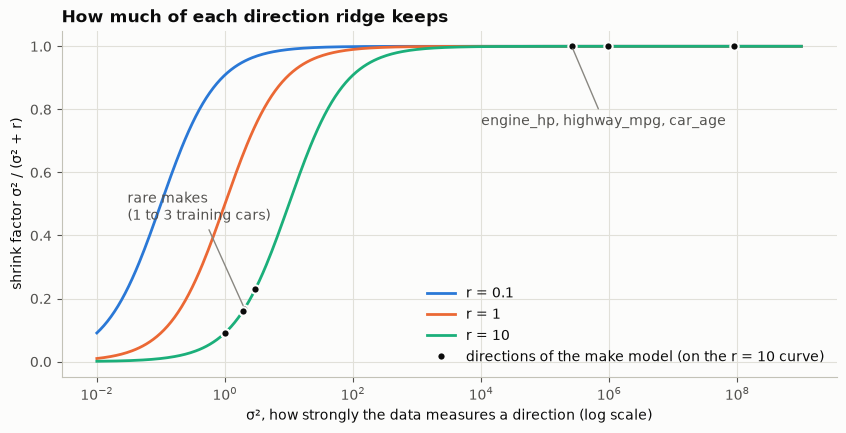

In [35]:
sigma2 = np.logspace(-2, 9, 400)
fig, ax = plt.subplots(figsize=(10, 4.5))
for r, color in [(0.1, BLUE), (1, ORANGE), (10, GREEN)]:
    ax.plot(sigma2, sigma2 / (sigma2 + r), color=color, label=f'r = {r}')

# The real directions of the make model from the table above, placed on the r = 10 curve.
real_sigma2 = np.array([row['sigma^2'] for row in rows])
ax.plot(real_sigma2, real_sigma2 / (real_sigma2 + 10), 'o', color=INK, markersize=6, markeredgecolor=BACKGROUND,
        markeredgewidth=1.5, label='directions of the make model (on the r = 10 curve)')
ax.annotate('rare makes\n(1 to 3 training cars)', xy=(2, 0.17), xytext=(0.03, 0.45),
            arrowprops=dict(arrowstyle='-', color=GREY), color='#52514e')
ax.annotate('engine_hp, highway_mpg, car_age', xy=(2.6e5, 1.0), xytext=(1e4, 0.75),
            arrowprops=dict(arrowstyle='-', color=GREY), color='#52514e')
ax.set_xscale('log')
ax.set_title('How much of each direction ridge keeps')
ax.set_xlabel('σ², how strongly the data measures a direction (log scale)')
ax.set_ylabel('shrink factor σ² / (σ² + r)')
ax.legend(loc='lower right')
plt.show()

**Reading the chart.** The horizontal axis is $\sigma^2$ for a direction (log scale), that is, how strongly the data measures it. The vertical axis is the shrink factor: the fraction of that direction's least-squares component that ridge keeps, from 0 (all removed) to 1 (untouched). Each colored curve is one value of r, and the black dots are the real directions of the make model from the table above, placed on the r = 10 curve.

Every curve passes 0.5 exactly where $\sigma^2 = r$. Directions far to the right of that point are kept almost whole, and directions far to the left are removed almost entirely. The make model's directions sit at the two extremes: the rare makes near $\sigma^2 \approx 1$ to 3, where r = 10 keeps only 9–23%, and the numerical columns at $10^5$ to $10^8$, which no r on this chart touches.

Exactly as predicted: the weakest directions are single rare makes, each with $\sigma^2$ close to its number of training cars. $r = 10$ keeps only 9–23% of those components and leaves the strong directions untouched. This is the Bugatti weight collapsing from +999% as $r$ grew in section 11 of the NumPy notebook.

The table also shows the caveat that notebook raised. The strongest direction is dominated by `engine_hp`, whose values run into the hundreds, so its $\sigma^2$ is enormous and no reasonable $r$ touches it. The penalty acts almost entirely on the 0/1 columns. How much a weight is shrunk depends on the units of its column, which is the argument for rescaling the columns before using ridge.

### 17. Conditioning and gradient descent

*Formalises section 9.*

**Gradient descent** on $L(w) = \tfrac{1}{2} \lVert y - Xw \rVert^2$ (the $\tfrac12$ only tidies the formulas) repeats

$$w_{k+1} = w_k - \eta\, \nabla L(w_k) = w_k - \eta\, X^T (X w_k - y)$$

with a step size $\eta > 0$. Let $H = X^T X$, with eigenvalues $\lambda_1 \ge \dots \ge \lambda_p > 0$ (so $\lambda_j = \sigma_j^2$), and let $w^\star$ be the solution. Since $X^T y = H w^\star$, the error $e_k = w_k - w^\star$ obeys

$$e_{k+1} = (I - \eta H)\, e_k , \qquad\text{so along the } j\text{-th eigenvector:}\quad e_{k+1, j} = (1 - \eta \lambda_j)\, e_{k, j} .$$

- **Stability** needs $\lvert 1 - \eta \lambda_j \rvert < 1$ for every $j$, i.e. $\eta < 2/\lambda_1$: the step size is capped by the *steepest* direction. Section 9 used $\eta = 1/\lambda_1$.
- With $\eta = 1/\lambda_1$, the slowest direction shrinks by the factor $1 - \lambda_p/\lambda_1 = 1 - 1/\kappa(H)$ per step. Reducing an error by a factor $\delta$ therefore takes about $\kappa(H) \ln(1/\delta)$ steps: **the number of steps grows in proportion to the condition number.**

Because the error recursion is linear, we can compute exactly how many steps each run of section 9 needs to get within 0.1% of the best score, without running millions of steps:

In [36]:
def steps_needed(X, y, tolerance=1e-3):
    # The exact number of gradient descent steps (eta = 1 / largest eigenvalue, starting from w = 0) until the
    # score is within `tolerance` of the best score, using e_k = (I - eta H)^k e_0 in the eigenbasis of H.
    H = X.T @ X
    lam, Q = np.linalg.eigh(H)
    eta = 1 / lam.max()
    w_star = np.linalg.solve(H, X.T @ y)
    c = Q.T @ (0 - w_star)                                # e_0 in the eigenbasis
    best = ((y - X @ w_star) ** 2).sum()

    def excess(k):                                        # score after k steps minus the best score
        return np.sum(lam * (1 - eta * lam) ** (2 * k) * c ** 2)

    lo, hi = 0, 1
    while excess(hi) > tolerance * best:
        hi *= 2
    while lo < hi:                                        # binary search for the first k that is close enough
        mid = (lo + hi) // 2
        lo, hi = (lo, mid) if excess(mid) <= tolerance * best else (mid + 1, hi)
    return lo, lam.max() / lam.min()


y_toy = cars.price.to_numpy(dtype=float)
for name, column in versions.items():
    steps, kappa = steps_needed(np.column_stack([np.ones(4), column]), y_toy)
    print(f'{name:20s} condition number {kappa:11,.1f}   steps needed {steps:>10,}')

horsepower as it is  condition number   961,942.5   steps needed  2,959,043
horsepower / 100     condition number       129.9   steps needed        348
standardised         condition number         1.0   steps needed          1


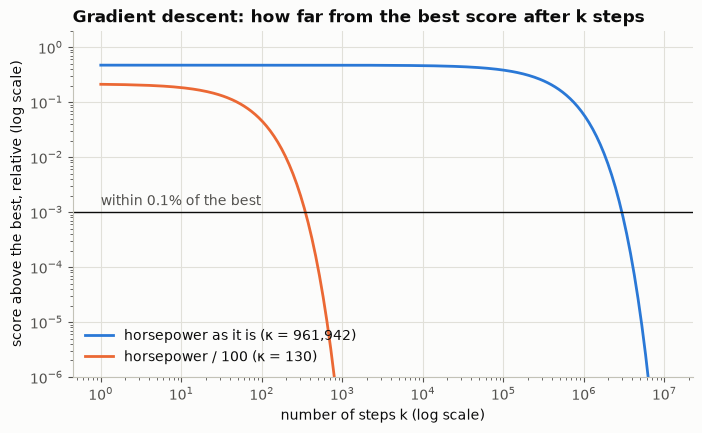

In [37]:
def relative_excess(X, y, ks):
    # (score after k steps - best score) / best score, for every k in ks, from the closed form above.
    H = X.T @ X
    lam, Q = np.linalg.eigh(H)
    eta = 1 / lam.max()
    w_star = np.linalg.solve(H, X.T @ y)
    c = Q.T @ (0 - w_star)
    best = ((y - X @ w_star) ** 2).sum()
    return np.array([np.sum(lam * (1 - eta * lam) ** (2 * k) * c ** 2) for k in ks]) / best


ks = np.unique(np.logspace(0, 7, 300).astype(int))
fig, ax = plt.subplots()
for name, color in [('horsepower as it is', BLUE), ('horsepower / 100', ORANGE)]:
    Xv = np.column_stack([np.ones(4), versions[name]])
    kappa = np.linalg.cond(Xv.T @ Xv)
    ax.plot(ks, relative_excess(Xv, y_toy, ks), color=color, label=f'{name} (κ = {kappa:,.0f})')
ax.axhline(1e-3, color=INK, linewidth=1)
ax.annotate('within 0.1% of the best', xy=(1, 1e-3), xytext=(0, 5), textcoords='offset points', color='#52514e')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-6, 2)
ax.set_title('Gradient descent: how far from the best score after k steps')
ax.set_xlabel('number of steps k (log scale)')
ax.set_ylabel('score above the best, relative (log scale)')
ax.legend(loc='lower left')
plt.show()

**Reading the chart.** The horizontal axis is the number of gradient descent steps, and the vertical axis is how far the score still is above the best score, relative to it; both are on log scales. Each curve stays flat for a while and then drops steeply, and the drop starts roughly when the number of steps reaches the condition number κ: around 100 steps for horsepower / 100 (κ = 130), and around a million for raw horsepower (κ = 961,942). The curves cross the 0.1% line at the 348 and 2,959,043 steps printed above. (The standardised version isn't drawn: it reaches the best score in a single step, and a log scale can't show a distance of 0.)

About 3κ steps in the first two cases, as the formula predicts: nearly three million with raw horsepower. Standardising makes κ = 1, so the valley is perfectly round and the first step lands at the bottom. (Standardising centres the column, which makes it orthogonal to the column of 1's, and scales it to the same length as that column, so $H$ becomes a multiple of $I$.)

The real matrices are much worse than the toy. The fixed door model has $\kappa(X^T X) \approx 2 \times 10^8$, and standardising brings it down to about 20:

In [38]:
X2_full = design(df_corrected, base + ['car_age', 'has_2_doors', 'has_3_doors'])
Z = X2_full.copy()
Z[:, 1:] = (Z[:, 1:] - Z[:, 1:].mean(axis=0)) / Z[:, 1:].std(axis=0)

print(f'unscaled:     cond(X^T X) = {np.linalg.cond(X2_full.T @ X2_full):.1e}')
print(f'standardised: cond(Z^T Z) = {np.linalg.cond(Z.T @ Z):.1f}')

unscaled:     cond(X^T X) = 2.2e+08
standardised: cond(Z^T Z) = 20.1


For plain gradient descent, that's roughly ten million times fewer steps. `'sag'` is a stochastic relative of gradient descent (it looks at one car at a time), and its speed also depends on how well conditioned the problem is. That's why it stopped half-way in the scikit-learn notebook and converged at once on standardised columns. Solvers that work on the matrix directly (`solve`, Cholesky, the SVD) take a fixed amount of work whatever the conditioning, though they still lose digits to it (section 13).

### 18. Summary: one table, two languages

| Part I, in plain language | Part II, in linear algebra |
|---|---|
| a model is a recipe: bias + weights × features (§1) | the predictions are $\hat y = Xw$, linear in $w$ (§10) |
| the best weights leave no pattern in the errors (§2) | the normal equations $X^T X w = X^T y$; the residual is orthogonal to $C(X)$; $\hat y$ is the projection of $y$ onto $C(X)$ (§11) |
| one column is an exact recipe of the others (§5) | the columns are linearly dependent: $N(X) \neq \{0\}$, $\operatorname{rank} X < p$ (§12) |
| the slide (§5) | the solutions form $w_0 + N(X)$, all with the same $\hat y$ (§12) |
| three disguises (§6) | the null vectors $e_{\text{bias}} - \sum e_{\text{door}}$, $e_{\text{popularity}} - \dots$ and $e_j$ (§12) |
| rounding hides the division by zero (§7) | a zero $\sigma_j$ becomes a tiny leftover; $\kappa(X^T X) = \kappa(X)^2$; relative error up to about $\kappa \varepsilon$ (§13) |
| pick the smallest weights (§8) | the pseudoinverse $w^+ = X^+ y$, the only solution orthogonal to $N(X)$ (§14) |
| drop a column (§8) | the column space stays the same, so $\hat y$ does too; $N(X) = \{0\}$, so $w$ is unique (§15) |
| ridge: penalise large weights (§8) | $(X^T X + rI)\, w = X^T y$; eigenvalues $+\, r$; shrink factors $\sigma_j^2 / (\sigma_j^2 + r)$; $w_r \to w^+$ as $r \to 0$ (§16) |
| rescale the columns for step-by-step solvers (§9) | gradient descent needs a number of steps proportional to $\kappa(X^T X)$; standardising lowers $\kappa$ (§17) |

The one rule of the whole project, *no column may be an exact recipe of the other columns*, is the statement $N(X) = \{0\}$. Everything else in this notebook is about what happens, numerically and statistically, when that rule fails, or almost fails.